# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFSCar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>

<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final — Classificação Automática de Documentos Jurídicos</center>

**Nome**: Anderson Cristiano Sassaki Gonçalves

**RA**: 821675

**Nome**: Lorenzo Grippo Chiachio

**RA**: 823917

---

### Contexto do problema

O Supremo Tribunal Federal (STF) recebe diariamente um volume enorme de peças processuais digitalizadas. Saber automaticamente o tipo do documento é o primeiro passo de qualquer automação de triagem jurídica. Este projeto usa uma partição da base **VICTOR**, contendo o texto bruto de páginas de processos do STF, rotuladas em cinco categorias:

| Código | Categoria |
|---|---|
| 0 | Acórdão |
| 1 | Agravo de Recurso Extraordinário (ARE) |
| 2 | Despacho |
| 3 | Recurso Extraordinário (RE) |
| 4 | Sentença |

O desafio combina três dificuldades típicas de PLN jurídico em português: **ruído de extração/OCR** , **vocabulário técnico-formulaico** e **forte desbalanceamento de classes**.

### Como o notebook está organizado

Este notebook implementa um pipeline completo de classificação de texto: exploração dos dados -> limpeza -> baselines clássicos -> embeddings densos -> modelo de linguagem ajustado (Legal-BERTimbau Large). O arquivo oficial submetido na competição é `submission_bert_large_final.csv`. A variante `submission_bert_large_final-cheating.csv` que aparece na análise final é **apenas uma análise de um exploit estrutural por `Id`/Viterbi**, documentada por transparência metodológica, e **nunca deve ser tratada como nossa submissão válida**.

Para melhorar a leitura, a narrativa agora segue quatro fases, inspiradas na estrutura do notebook de referência:

1. **Preparação inicial e análise dos dados:** configuração do ambiente, carregamento dos CSVs e entendimento do corpus;
2. **Limpeza, representação e tarefas básicas de PLN:** normalização textual, diagnóstico dos rótulos, construção de features e escolha das representações;
3. **Modelagem e geração de submissões:** comparação de modelos clássicos, embeddings densos e Legal-BERTimbau Large;
4. **Análise comparativa dos resultados:** consolidação dos resultados, gráficos, comparação entre modelos e separação entre submissão honesta e experimento com exploit.

Os oito tópicos do enunciado anterior foram preservados como subtópicos dentro dessas fases. Assim, a estrutura fica mais parecida com uma história de projeto, sem perder a rastreabilidade das etapas técnicas.

---
## Fase 1 — Preparação inicial e análise dos dados

Esta fase prepara o ambiente de execução e estabelece o ponto de partida empírico do projeto. Primeiro resolvemos dependências, diretórios e imports; depois carregamos `train.csv`, `test.csv` e `sample_submission.csv`, validamos o schema e investigamos distribuição de classes, tamanho dos textos, termos frequentes e exemplos do corpus.

### Preparação do ambiente

As células seguintes verificam as dependências, definem os diretórios do projeto, importam as funções implementadas em `scripts/` (organizadas por etapa: `analise_exploratoria.py`, `preprocessamento.py`, `experimentos.py` e `analise_resultados.py`) e selecionam automaticamente o melhor dispositivo disponível (`cuda`, `mps` ou `cpu`). Essa preparação é comum a todo o pipeline.

Para manter a reprodutibilidade do resultado final sem tornar o notebook excessivamente longo, o treinamento completo do Legal-BERTimbau Large fica encapsulado no script `train_bert_large_final.py`. O notebook mostra exatamente como esse script é chamado, quais artefatos ele gera e como interpretar as submissões produzidas, mas a execução pesada (que demanda GPU e leva horas) permanece opcional e desligada por padrão.

In [1]:
import importlib.util
import subprocess
import sys

BASE_MODULES = ["pandas", "numpy", "sklearn", "matplotlib", "seaborn", "joblib"]
ADVANCED_MODULES = ["torch", "transformers", "datasets", "sentence_transformers", "accelerate"]

missing_base = [pkg for pkg in BASE_MODULES if importlib.util.find_spec(pkg) is None]
if missing_base:
    print("Instalando dependências base ausentes:", missing_base)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Dependências base já disponíveis.")

missing_advanced = [pkg for pkg in ADVANCED_MODULES if importlib.util.find_spec(pkg) is None]
if missing_advanced:
    print("Instalando dependências avançadas ausentes:", missing_advanced)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-advanced.txt"])
else:
    print("Dependências avançadas já disponíveis.")

importlib.invalidate_caches()
print("Ambiente pronto para executar o pipeline completo.")


Dependências base já disponíveis.
Dependências avançadas já disponíveis.
Ambiente pronto para executar o pipeline completo.


Dependências resolvidas, o ambiente está pronto. A célula a seguir resolve os caminhos do projeto (`data/`, `outputs/`, `models/`), garante que as pastas de saída existam, adiciona `scripts/` ao `sys.path` para permitir os imports dos módulos do projeto, e importa todas as funções que serão usadas ao longo do notebook — uma por seção. Por fim, `auto_runtime_profile` inspeciona o hardware disponível (CPU/CUDA/MPS) e devolve um perfil de execução: ele decide automaticamente o tamanho de batch e a precisão numérica recomendados para o Transformer, sem exigir que configuremos manualmente flags diferentes em cada máquina.

In [2]:
from pathlib import Path
import json
import os
import platform
import subprocess
import sys

import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd()
if (PROJECT_DIR / "template-implementacao" / "scripts").exists():
    PROJECT_DIR = PROJECT_DIR / "template-implementacao"
PROJECT_DIR = PROJECT_DIR.resolve()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models"
CACHE_DIR = OUTPUT_DIR / "cache"
REPORT_DIR = OUTPUT_DIR / "reports"

for directory in [OUTPUT_DIR, MODEL_DIR, CACHE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

sys.path.append(str((PROJECT_DIR / "scripts").resolve()))

from analise_exploratoria import (
    add_text_statistics,
    get_top_terms,
    load_competition_data,
    plot_class_distribution,
    plot_text_length_distribution,
    plot_top_terms,
    summarize_dataset,
    validate_schema,
    split_labeled_unlabeled,
)
from preprocessamento import (
    CLASS_NAMES,
    TextPreprocessConfig,
    add_clean_text_column,
    extract_basic_nlp_features,
    extract_legal_signal_features,
)
from experimentos import (
    ExperimentConfig,
    auto_runtime_profile,
    build_embedding_classifier_zoo,
    build_sentence_embedding_matrix,
    build_chunked_sentence_embedding_matrix,
    build_sparse_model_zoo,

    build_training_set_with_pseudo_labels,
    cross_validate_best_models,

    detect_label_issues_with_cv,
    evaluate_embedding_classifier,
    evaluate_model_zoo,
    fine_tune_transformer_classifier,
    fit_embedding_classifier_on_full_train,
    fit_model_on_full_train,
    generate_embedding_submission,
    generate_submission,
    generate_transformer_submission,

    pseudo_label_unlabeled_samples,
    save_model,
    select_best_model,
    transformer_candidate_models,
)
from analise_resultados import (
    classification_report_frame,
    plot_confusion_matrix,
    plot_metric_comparison,
    rank_results,
    save_results_table,
)

pd.set_option("display.max_colwidth", 160)

runtime_profile = auto_runtime_profile(prefer_transformer=True)
print("Diretório do projeto:", PROJECT_DIR)
print("Perfil automático:", runtime_profile["notes"])
display(pd.DataFrame([
    {
        "device": runtime_profile["device"],
        "advanced_available": runtime_profile["advanced_available"],
        "classical_model_zoo": runtime_profile["classical_model_zoo"],
        "run_classical_baselines": runtime_profile["run_classical_baselines"],
        "run_embeddings": runtime_profile["run_embeddings"],
        "run_transformer": runtime_profile["run_transformer"],
        "batch_transformer": runtime_profile["transformer_batch_size"],
        "max_length_transformer": runtime_profile["transformer_max_length"],
    }
]))


Diretório do projeto: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao
Perfil automático: Complete pipeline enabled automatically on mps.


,device,advanced_available,classical_model_zoo,run_classical_baselines,run_embeddings,run_transformer,batch_transformer,max_length_transformer
0,mps,True,full,True,True,True,2,512


### 1. Análise de dados

Nesta seção, os arquivos `train.csv`, `test.csv` e `sample_submission.csv` são carregados e validados quanto ao schema esperado (colunas presentes, tipos e valores nulos). Amostras com rótulos fora do intervalo `0`–`4` (ou seja, `Category = -1`) são separadas do conjunto rotulado, elas não serão usadas para treino supervisionado, mas são preservadas para uma possível pseudo-rotulagem mais adiante, na Seção 5.

A análise exploratória a seguir examina:

- a distribuição das classes (e o quão desbalanceado é o problema);
- a presença de dados ausentes ou inconsistentes;
- o comprimento dos documentos (em caracteres e palavras) por categoria;
- os termos mais frequentes/discriminativos por categoria, via TF-IDF.

Esses resultados orientam diretamente decisões técnicas tomadas mais adiante: o uso de `f1_macro` como métrica principal, o balanceamento de classes nos modelos, a escolha de n-gramas robustos a ruído de OCR e as estratégias adotadas para lidar com documentos muito longos.

Começamos carregando os três arquivos da competição e validando o schema. `split_labeled_unlabeled` separa as linhas com `Category` válida (usadas como treino supervisionado) das linhas com `Category = -1` (sem rótulo confiável).

In [3]:
train_df, test_df, sample_df = load_competition_data(DATA_DIR)
schema_report = validate_schema(train_df, test_df, sample_df)
train_labeled, train_unlabeled = split_labeled_unlabeled(train_df)

print(f"Total no train.csv: {len(train_df)}")
print(f"Amostras rotuladas válidas: {len(train_labeled)}")
print(f"Amostras sem rótulo válido (Category=-1 ou fora de 0..4): {len(train_unlabeled)}")
print(f"Amostras de teste: {len(test_df)}")

print("Classes usadas no treinamento:")
for label, name in CLASS_NAMES.items():
    print(f"{label}: {name}")

schema_report


Total no train.csv: 22680
Amostras rotuladas válidas: 20412
Amostras sem rótulo válido (Category=-1 ou fora de 0..4): 2268
Amostras de teste: 2521
Classes usadas no treinamento:
0: Acordao
1: Agravo de Recurso Extraordinario (ARE)
2: Despacho
3: Recurso Extraordinario (RE)
4: Sentenca


{'train_shape': (22680, 3),
 'test_shape': (2521, 2),
 'sample_shape': (15, 2),
 'train_missing_columns': [],
 'test_missing_columns': [],
 'sample_missing_columns': [],
 'train_nulls': {'Id': 0, 'Body': 0, 'Category': 0},
 'test_nulls': {'Id': 0, 'Body': 0},
 'duplicated_train_ids': 0,
 'duplicated_test_ids': 0,
 'invalid_category_count': 2268,
 'invalid_category_examples': [{'Id': 9716, 'Category': -1},
  {'Id': 25112, 'Category': -1},
  {'Id': 11274, 'Category': -1},
  {'Id': 20985, 'Category': -1},
  {'Id': 23109, 'Category': -1},
  {'Id': 21386, 'Category': -1},
  {'Id': 21334, 'Category': -1},
  {'Id': 20980, 'Category': -1},
  {'Id': 18398, 'Category': -1},
  {'Id': 7787, 'Category': -1}]}

O `train.csv` tem **22.680 linhas**, das quais **20.412 (≈90%)** possuem rótulo válido e **2.268 (exatamente 10%)** vêm marcadas com `Category = -1`, um padrão de ausência de rótulo bastante regular. O `test.csv` tem **2.521 amostras** a serem classificadas. O relatório de integridade confirma que não há colunas ausentes, não há valores nulos em `Id`/`Body`/`Category`, e não há IDs duplicados em nenhum dos dois arquivos, ou seja, o ruído deste dataset está concentrado no *conteúdo* do texto.

Antes de qualquer estatística, é sempre bom olhar literalmente para os dados, ver como o texto bruto se parece, quais colunas o `test.csv` realmente expõe e o formato de `sample_submission.csv`.

In [4]:
display(train_labeled.head())
display(test_df.head())
if sample_df is not None:
    display(sample_df.head())

,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido co...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem ativi...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedi...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o paraÃ­ba geral isonomia contido ARTIGO_5Âº caput cf e preceito que garante isonomia entre servidores ativos ina...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional campina grande paga pelo inss modo garantir empregado manu...",3


,Id,Body
0,9213,"{""um regime democrática direito qual seja da separação dos poderes recurso inominado parte autora improvido sem condenação ônus sucumbenciais por força conc..."
1,17427,"{""controvérsia fato que requerente participante rpps junto prefeitura municipal roca sales desde que valores atinentes aposentadorias rurais não são essenci..."
2,4753,"{""advocacia geral união procuradoria união paraíba excelentíssimo senhor juiz federal presidente turma recursal dos juizados especiais paraíba união por sua..."
3,4640,"{""advocacia geral união procuradoria união estado paraíba divisão atuação nos juizados especiais federais ARTIGO_169 despesa com pessoal ativo inativo união..."
4,20412,"{""ministério fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional campina grande pede deferimento campina grande de dezembro ..."


,Id,Category
0,7271,3
1,861,4
2,5391,0
3,5192,3
4,5735,1


A visualização confirma a estrutura dos arquivos usados no experimento. O conjunto de treino rotulado contém as colunas `Id`, `Body` e `Category`, em que cada texto jurídico já aparece associado à sua classe. Nas primeiras amostras já é possível observar a predominância da classe `3`, um indício do desbalanceamento que será analisado nas próximas etapas. O conjunto de teste mantém a mesma estrutura textual, com `Id` e `Body`, mas não possui a coluna `Category`, pois é justamente sobre esses exemplos que o modelo deve produzir previsões. Por fim, o arquivo de submissão de exemplo mostra o formato esperado pela competição: uma linha por `Id` e uma categoria prevista na coluna `Category`.

Após analisar os dados brutos, calculamos a distribuição de classes, valores ausentes e um resumo estatístico do comprimento dos documentos (`n_chars`, `n_words`, `unique_word_ratio`) por categoria.

In [5]:
eda = summarize_dataset(train_labeled)
train_stats = eda["data_with_stats"]

print("Distribuição de classes")
display(eda["class_distribution"])

print("Valores ausentes")
display(eda["missing_summary"])

print("Resumo de tamanho por classe")
display(eda["length_summary"])


Distribuição de classes


,Category,count,percent
3,0,665,3.257888
1,1,3529,17.288850
4,2,439,2.150696
0,3,12876,63.080541
2,4,2903,14.222026


Valores ausentes


,missing
Id,0
Body,0
Category,0


Resumo de tamanho por classe


n_chars                                                           \
            count         mean         std    min      25%     50%     75%   
Category                                                                     
0           665.0  2011.908271  907.395586  155.0  1292.00  2119.0  2615.0   
1          3529.0  1578.096345  735.338974    4.0  1086.00  1456.0  2016.0   
2           439.0  1195.735763  852.372715  113.0   443.00  1154.0  1508.5   
3         12876.0  1746.595216  704.201052   33.0  1360.75  1712.0  2124.0   
4          2903.0  2046.951085  771.020978   94.0  1602.00  1931.0  2640.0   

                  n_words              ...               unique_word_ratio  \
             max    count        mean  ...    75%    max             count   
Category                               ...                                   
0         4798.0    665.0  251.539850  ...  326.0  576.0             665.0   
1         5702.0   3529.0  195.200057  ...  248.0  685.0            3529.0   
2         6867.0    439.0  149.036446  ...  186.5  844.0             439.0   
3         5923.0  12876.0  213.882883  ...  260.0  781.0           12876.0   
4         6448.0   2903.0  254.391319  ...  324.0  837.0            2903.0   

                                                                           
              mean       std       min       25%       50%       75%  max  
Category                                                                   
0         0.773313  0.095599  0.493671  0.719008  0.772727  0.827206  1.0  
1         0.765190  0.088360  0.287037  0.708812  0.768293  0.821138  1.0  
2         0.771077  0.125442  0.496445  0.655629  0.750000  0.867839  1.0  
3         0.748295  0.080344  0.311450  0.700472  0.748503  0.796667  1.0  
4         0.712588  0.096364  0.322464  0.648438  0.698551  0.768298  1.0  

[5 rows x 24 columns]

Os números confirmam um desbalanceamento severo: a classe **3 (Recurso Extraordinário)** domina com **63,08%** das amostras rotuladas (12.876 linhas), seguida por **1 (ARE)** com 17,29% e **4 (Sentença)** com 14,22%. As classes **0 (Acórdão)** e **2 (Despacho)** somam juntas menos de **5,5%** do corpus (665 e 439 amostras, respectivamente). Esse padrão é o motivo pelo qual escolhemos `f1_macro` como métrica principal: um modelo que apenas "chuta" sempre a classe 3 atingiria *accuracy* alta, mas falharia completamente nas classes minoritárias, e o `f1_macro` penaliza isso ao dar peso igual a cada classe.

Não há valores ausentes em nenhuma das colunas relevantes (`Id`, `Body`, `Category`), o que reforça que toda a sujeira do problema está no conteúdo textual, e não na estrutura tabular. Em termos de tamanho, as categorias **0 (Acórdão)** e **4 (Sentença)** tendem a produzir documentos mais longos (médias de 252 e 254 palavras), enquanto **2 (Despacho)** é consistentemente mais curta (média de 149 palavras) ,uma pista útil, já que despachos costumam ser textos administrativos breves, enquanto acórdãos e sentenças trazem fundamentação mais extensa.

Visualizamos essa distribuição de classes e a distribuição do comprimento dos documentos (em palavras) para confirmar visualmente os números da tabela acima.

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Distribuicao de n_words'}, xlabel='n_words', ylabel='Count'>,
        <Axes: title={'center': 'n_words por categoria'}, xlabel='Categoria', ylabel='n_words'>],
       dtype=object))

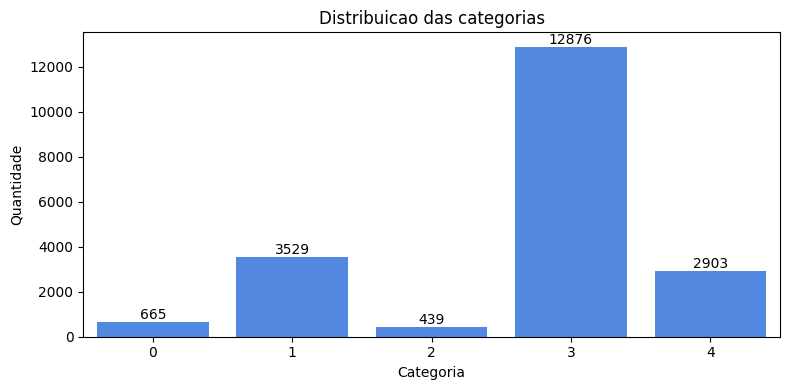

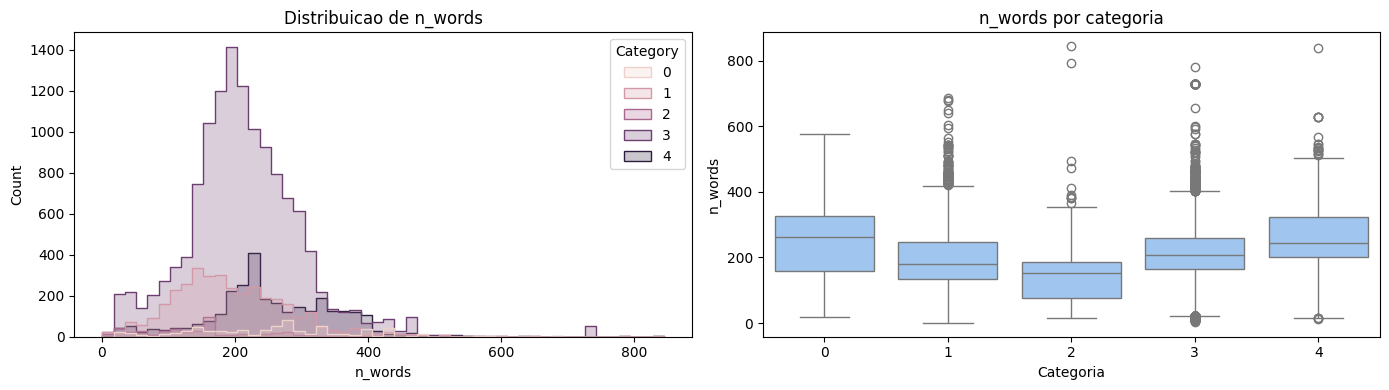

In [6]:
plot_class_distribution(eda["class_distribution"])
plot_text_length_distribution(train_stats, metric="n_words")

O histograma de barras evidencia visualmente a dominância da classe 3 sobre as demais, e o boxplot por categoria confirma a tendência observada nos números: Acórdão e Sentença têm caudas mais longas (documentos extensos e variáveis), enquanto Despacho se concentra em textos mais curtos.

Por fim, usamos TF-IDF para extrair os termos mais característicos de cada categoria. Isso funciona como uma checagem de sanidade qualitativa: se os termos top do TF-IDF fizerem sentido jurídico para a categoria, ganhamos confiança de que o rótulo está consistente com o conteúdo do texto.

,Category,rank,term,mean_tfidf
0,0,1,que,0.036902
1,0,2,dos,0.031524
2,0,3,nã,0.029471
3,0,4,por,0.026011
4,0,5,para,0.024199
5,0,6,nos,0.023581
6,0,7,federal,0.023564
7,0,8,recurso,0.022596
8,0,9,com,0.022066
9,0,10,relator,0.021224


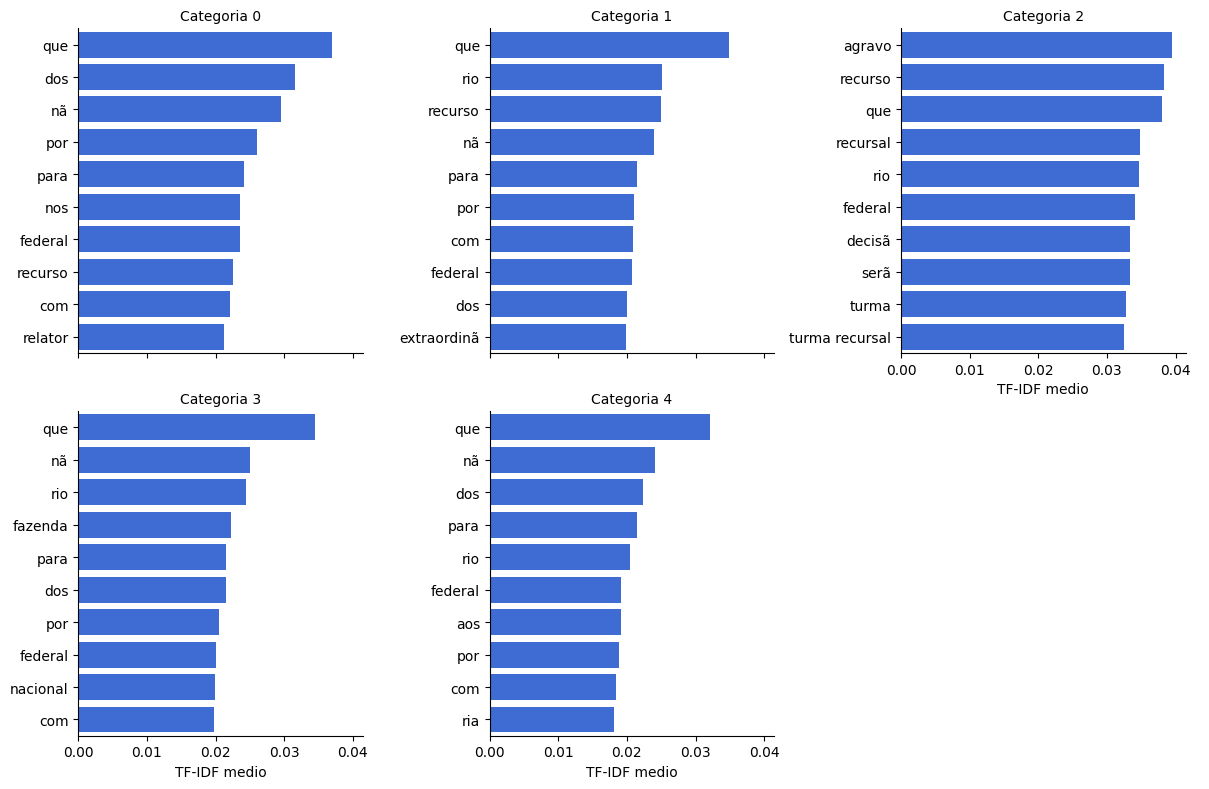

In [7]:
top_terms = get_top_terms(train_labeled, n_terms=12)
display(top_terms.head(30))
plot_top_terms(top_terms, n_terms=10)

Os termos mais relevantes por classe revelam vocabulário jurídico coerente com cada categoria: a classe **2 (Despacho)** destaca termos como *agravo*, *recursal* e *recurso*, típicos de movimentações processuais; outras classes trazem termos processuais genéricos (*recurso*, *federal*, *relator*, *turma*), o que é esperado em um corpus do STF, já que boa parte do vocabulário é compartilhado entre as classes, e a separação real provavelmente depende mais de combinações de termos e de estrutura do documento do que de palavras isoladas. Isso já sugere que **n-gramas de palavras e de caracteres** (e não apenas unigramas) tendem a ajudar os modelos clássicos a capturar esses padrões.

## Fase 2 — Limpeza, representação e tarefas básicas de PLN

### 2. Pré-processamento e limpeza

Os documentos podem conter ruídos típicos de extração de PDFs jurídicos via OCR: quebras artificiais de linha, hifenização incorreta, assinaturas digitais, carimbos, números de processo e referências legais em formatos variados (datas, valores monetários, artigos de lei). A limpeza implementada em `preprocessamento.py` produz a coluna `Body_clean`, que serve como interface estável entre os dados brutos e os modelos, qualquer modelo clássico do pipeline consome `Body_clean`, e não o texto bruto.

As principais operações de limpeza são: normalização de caixa e acentos, remoção de URLs e e-mails, padronização de referências jurídicas (datas, valores monetários e citações de artigos de lei tornam-se tokens especiais como `DATA`, `VALOR_MONETARIO` e `ARTIGO_LEI`), além da filtragem de tokens muito curtos. As *stopwords* são deliberadamente **preservadas**, pois fórmulas funcionais frequentes no juridiquês (como conectivos e preposições em expressões fixas) podem ajudar a caracterizar o tipo de documento, entendemos que removê-las poderia destruir um sinal útil.

Aplicamos a limpeza configurada acima tanto ao treino rotulado quanto ao teste, gerando a coluna `Body_clean` em ambos. Exibimos três exemplos para comparar visualmente o texto bruto (`Body`) com o texto limpo (`Body_clean`).

In [8]:
preprocess_config = TextPreprocessConfig(
    lowercase=True,
    strip_accents=True,
    normalize_legal_refs=True,
    remove_urls_emails=True,
    remove_stopwords=False,
    min_token_len=2,
    keep_digits=False,
)

train_clean = add_clean_text_column(train_labeled, config=preprocess_config)
test_clean = add_clean_text_column(test_df, config=preprocess_config)

train_clean[["Id", "Category", "Body", "Body_clean"]].head(3)


,Id,Category,Body,Body_clean
0,12980,3,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido co...",conclusao diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro artigo_ iii constituicao federal sera admitido conhecido p...
1,9775,3,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem ativi...",artigo_ gecen gacen serao devidas aos titulares dos empregos cargos publicos que tratam artigo_ desta lei que carater permanente realizarem atividades comba...
2,16061,1,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedi...",seguir desacerto decisao que negou seguimento recurso extraordinario equivoco decisao discutida constitucionalidade prazo minimo anos para que impedimento p...


A comparação entre `Body` e `Body_clean` evidencia o impacto da limpeza: o texto bruto chega com mojibake (`Ã©`, `Ã£`) resultante de problemas de codificação na extração de OCR, além de estar envolto em um wrapper `{"texto"}` literal. Após a limpeza, o texto fica normalizado (sem acentos, em minúsculas) e referências legais como números de artigo são convertidas em tokens padronizados (`artigo_`). Isso reduz a esparsidade do vocabulário sem descartar a informação estrutural de que *existe* uma referência a um artigo de lei naquele ponto do texto, o que pode ser um sinal relevante para diferenciar, por exemplo, Recursos Extraordinários de Despachos.

Recalculamos as estatísticas de comprimento, agora sobre o texto já limpo, para observar como a normalização alterou a distribuição de tamanhos dos documentos.

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Distribuicao de n_words'}, xlabel='n_words', ylabel='Count'>,
        <Axes: title={'center': 'n_words por categoria'}, xlabel='Categoria', ylabel='n_words'>],
       dtype=object))

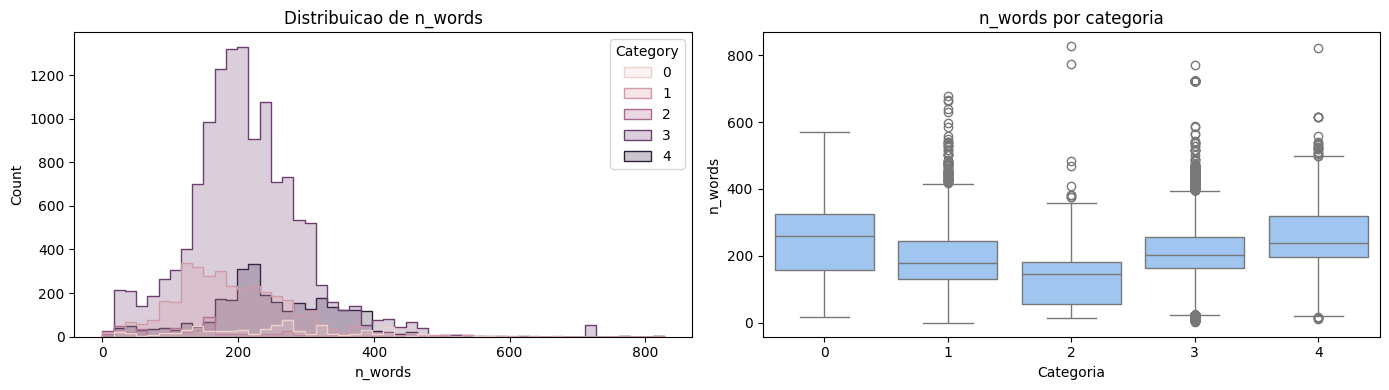

In [9]:
train_clean_stats = add_text_statistics(train_clean, text_col="Body_clean")
plot_text_length_distribution(train_clean_stats, metric="n_words")

### Diagnóstico do conjunto de treinamento

Antes de seguir para a representação computacional, vale documentar achados adicionais que vieram de uma inspeção mais cuidadosa do `train.csv`.

O conjunto contém **22.680 amostras**, mas **2.268** delas possuem `Category = -1` e como dito anteriormente, não podem ser usadas diretamente como exemplos supervisionados. Entre as **20.412 amostras com rótulo válido**, foram observados adicionalmente:

- **2.272 grupos de textos exatamente repetidos**, abrangendo **12.115 linhas**, ou seja, mais da metade do conjunto rotulado tem alguma duplicata textual exata;
- **21 grupos de textos idênticos associados a classes válidas diferentes**, totalizando **58 linhas**. Os conflitos aparecem especificamente entre as classes `1` (ARE) e `3` (RE), e entre as classes `2` (Despacho) e `4` (Sentença);
- documentos extensos, que exigem atenção especial nas representações neurais com janela de contexto limitada.

É importante separar dois fenômenos diferentes aqui: uma **duplicata não é necessariamente um erro**, já que ela pode representar conteúdo legítimo repetido entre peças de um mesmo processo, ou trechos padronizados reaproveitados em vários documentos. Já um **texto idêntico associado a classes diferentes** constitui uma ambiguidade genuína, que não pode ser resolvida apenas pelo conteúdo textual (são indistinguíveis a partir do `Body`). Por isso, o pipeline evita descartar ou sobrescrever esses exemplos de forma indiscriminada, preferindo tratá-los com a auditoria de rótulos feita na Seção 5.

### Estratégias adotadas pelo pipeline

O código adota uma postura conservadora: na dúvida, prefere preservar os dados a descartar informações que podem ser úteis. As principais estratégias implementadas são:

1. **Separação de dados sem rótulo:** Textos com categorias inválidas são isolados desde o início para não contaminar a avaliação dos modelos. Eles são guardados para uso posterior.
2. **Limpezas de texto sob medida:**
   * **Para os modelos básicos (baselines):** O texto é padronizado e limpo (removendo URLs e e-mails), mas palavras estruturais do jargão jurídico são mantidas.
   * **Para o Transformer (BERT):** A limpeza é mais leve, preservando letras maiúsculas, acentos e números, pois esses modelos avançados conseguem extrair significado dessa formatação.
3. **Auditoria e correção de rótulos:** O código procura falhas na rotulagem original e só faz correções automáticas quando o modelo detecta um erro com altíssima confiança.
4. **Pseudo-rotulagem rigorosa:** Os dados inicialmente sem rótulo só são reaproveitados e incluídos no treinamento se o modelo conseguir prever sua categoria com um nível de certeza extremamente conservador.
5. **Tratamento do desbalanceamento:** Para evitar que a classe com mais documentos domine o modelo, o pipeline utiliza métricas equilibradas (*F1-macro*) e aplica pesos diferentes para cada categoria.
6. **Lidando com documentos longos:** Textos extensos são divididos em blocos menores (com uma pequena sobreposição entre eles) para respeitar o limite máximo de leitura das redes neurais.
7. **Duplicatas e exploração da sequência de IDs:** Cópias exatas de texto servem apenas como um apoio secundário de probabilidade. **Ressalta-se que a previsão baseada no padrão sequencial dos IDs foi analisada puramente como um diagnóstico de vulnerabilidade, e não é utilizada na submissão final.**

**Observação sobre validação:** 
Nesta versão, as duplicatas não são removidas antes de separar os dados de treino e teste. Embora a auditoria amenize inconsistências, ainda há um leve risco de que partes do mesmo texto caiam em grupos diferentes. Uma recomendação futura é agrupar os textos idênticos antes da divisão, garantindo uma avaliação de desempenho ainda mais rigorosa.

### 3. Representação computacional

Com o texto limpo, o próximo passo é transformar cada documento em uma forma numérica que possa ser consumida pelos modelos. No nosso pipeline, essa representação não é única: diferentes famílias de modelos enxergam o texto por perspectivas complementares.

- **TF-IDF de palavras:** representa o documento pela importância relativa dos termos, preservando vocabulário jurídico recorrente, expressões processuais e combinações de palavras relevantes para cada classe;
- **TF-IDF de caracteres:** captura padrões menores que palavras completas, o que é útil em textos com ruído de OCR, variações de grafia, abreviações e marcações normalizadas;
- **atributos de domínio:** resumem propriedades interpretáveis do texto, como tamanho, diversidade lexical, referências a artigos/processos/datas e densidade de palavras-chave jurídicas;
- **embeddings densos e modelos de linguagem:** representam os documentos em vetores contextuais, capazes de capturar relações semânticas que não aparecem apenas por contagem de termos.

Essa separação é importante porque evita tratar a representação textual como uma escolha puramente técnica. Em textos jurídicos, a forma como o documento é codificado influencia diretamente quais pistas o modelo consegue perceber: vocabulário literal, padrões de escrita, estrutura processual ou contexto semântico.

Antes dos modelos propriamente ditos, calculamos uma representação tabular simples e interpretável com `extract_legal_signal_features`.Sua função é tornar visíveis alguns sinais do domínio jurídico que aparecem nos textos: tamanho do documento, proporção de dígitos e maiúsculas, diversidade lexical, referências processuais e frequência relativa de termos associados às classes.

In [10]:
legal_features = extract_legal_signal_features(train_clean, text_col="Body_clean")

print("Features jurídicas:", legal_features.shape)
display(legal_features.head())

Features jurídicas: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,56,430,0.0,0.0,0.928571,0,0,0,0.017857,0.000000,0.000000,0.017857,0.000000,0.0
1,136,1009,0.0,0.0,0.720588,0,0,0,0.000000,0.036765,0.007353,0.000000,0.000000,0.0
2,203,1649,0.0,0.0,0.802956,0,0,0,0.000000,0.000000,0.004926,0.009852,0.000000,0.0
3,309,2440,0.0,0.0,0.692557,0,0,2,0.003236,0.000000,0.000000,0.009709,0.000000,0.0
4,458,3465,0.0,0.0,0.655022,0,0,1,0.028384,0.002183,0.006550,0.002183,0.010917,0.0


A saída possui **14 atributos por documento**. Eles mostram que a representação computacional também pode ser explicável: em vez de apenas gerar vetores de alta dimensão, conseguimos observar diretamente propriedades como extensão do texto, presença de marcadores jurídicos e densidade de termos relacionados a acórdão, ARE, despacho, RE e sentença.

Essas variáveis são especialmente úteis para diagnóstico. Quando um documento contém sinais de mais de uma classe, por exemplo, isso ajuda a explicar confusões posteriores entre categorias juridicamente próximas. Por outro lado, elas são deliberadamente simples: servem como apoio interpretativo e não como substituto das representações mais fortes usadas nos modelos das próximas seções.

### 4. Tarefas básicas de PLN

As tarefas básicas de PLN usadas no pipeline incluem:

- **normalização textual:** padronização de caixa, espaços, ruídos de codificação e substituição de padrões sensíveis por marcadores consistentes;
- **tokenização e contagem lexical:** divisão do texto em unidades de palavra para medir tamanho, diversidade vocabular e frequência relativa de termos;
- **identificação de padrões jurídicos:** reconhecimento de referências recorrentes, como números de processo, artigos de lei, datas e expressões típicas de cada classe;
- **extração de sinais linguísticos estruturados:** quando há analisadores linguísticos disponíveis, tarefas como PoS tagging e reconhecimento de entidades nomeadas podem acrescentar informações morfossintáticas e semânticas.

In [12]:
nlp_features = extract_basic_nlp_features(train_clean, text_col="Body")

print("Features básicas de PLN:", nlp_features.shape)
display(nlp_features.head())

Features básicas de PLN: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,56,430,0.0,0.0,0.928571,0,0,0,0.017857,0.000000,0.000000,0.017857,0.000000,0.0
1,136,1009,0.0,0.0,0.720588,0,0,0,0.000000,0.036765,0.007353,0.000000,0.000000,0.0
2,203,1649,0.0,0.0,0.802956,0,0,0,0.000000,0.000000,0.004926,0.009852,0.000000,0.0
3,309,2440,0.0,0.0,0.692557,0,0,2,0.003236,0.000000,0.000000,0.009709,0.000000,0.0
4,458,3465,0.0,0.0,0.655022,0,0,1,0.028384,0.002183,0.006550,0.002183,0.010917,0.0


A tabela resume os documentos por atributos linguístico-jurídicos básicos. O ponto central aqui não é o ganho de desempenho, mas a leitura do corpus: documentos mais longos tendem a carregar mais fórmulas processuais, referências normativas e expressões de classe; documentos com menor diversidade lexical podem refletir peças mais padronizadas; e a presença de marcadores como artigos, datas e referências processuais ajuda a caracterizar o tipo de decisão.

Essas informações tornam o pipeline mais auditável. Elas permitem relacionar erros de classificação a pistas concretas do texto e ajudam a explicar por que certas classes se aproximam semanticamente. Assim, a seção de tarefas básicas de PLN funciona como uma ponte entre a limpeza dos dados e os modelos: ela mostra quais propriedades linguísticas simples foram extraídas antes de passarmos para representações estatísticas e modelos profundos.

## Fase 3 — Modelagem e geração de submissões

### 5. Modelos de classificação clássicos

Os modelos clássicos estabelecem baselines fortes e computacionalmente eficientes, usando TF-IDF como representação. A bateria de modelos (`build_sparse_model_zoo`) inclui:

- `dummy_most_frequent`: baseline ingênuo que sempre prevê a classe majoritária. Referência para saber o piso de desempenho;
- `complement_nb_word_tfidf`: Complement Naïve Bayes, adequado a classes desbalanceadas;
- `logreg_word_tfidf`: Regressão Logística com `class_weight="balanced"`;
- `linear_svc_char_tfidf`: SVM linear sobre n-gramas de caracteres (3 a 5), mais robusto a ruído de OCR;
- `sgd_logloss_word_tfidf`: SGD com perda logística e regularização elastic net;
- `logreg_word_char_union` e `linear_svc_calibrated_word_char_union`: combinações (`FeatureUnion`) de TF-IDF de palavras e de caracteres.

O protocolo de avaliação segue três passos: primeiro, todos os modelos são comparados em um holdout estratificado (80/20); em seguida, os três melhores por `f1_macro` passam por validação cruzada (5 *folds*) para confirmar a estabilidade do ranking; por fim, o modelo vencedor é examinado em detalhe via matriz de confusão e relatório por classe. Depois disso, auditamos possíveis rótulos incorretos (usando os achados de duplicatas conflitantes da Seção 2), atribui pseudo-rótulos de alta confiança às amostras sem categoria válida, e treina o modelo clássico final sobre o conjunto ampliado.

Treinamos e avaliamos toda a bateria de modelos clássicos no holdout estratificado, ordenando pelo `f1_macro`.

,model,f1_macro,f1_weighted,accuracy,precision_macro,recall_macro
0,sgd_logloss_word_tfidf,0.905540,0.923211,0.923341,0.910771,0.902004
1,linear_svc_char_tfidf,0.900506,0.920781,0.920402,0.903173,0.899231
2,linear_svc_calibrated_word_char_union,0.900175,0.920244,0.921136,0.918387,0.884778
3,logreg_word_tfidf,0.894100,0.908926,0.906931,0.887711,0.904964
4,logreg_word_char_union,0.892553,0.907348,0.905462,0.880537,0.907837
5,complement_nb_word_tfidf,0.821108,0.857668,0.853539,0.779156,0.877840
6,dummy_most_frequent,0.154701,0.487822,0.630664,0.126133,0.200000


Resultados holdout salvos em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/model_results_holdout.csv


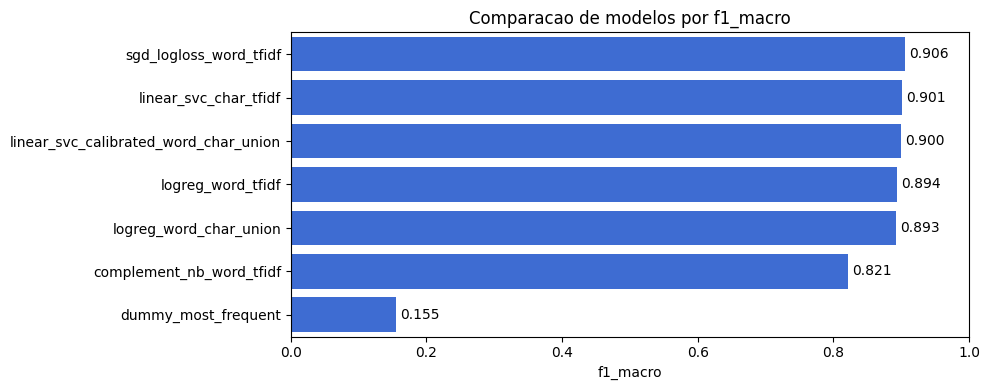

In [22]:
experiment_config = ExperimentConfig(
    text_col="Body_clean",
    target_col="Category",
    id_col="Id",
    random_state=42,
    validation_size=0.2,
    cv_folds=5,
    scoring="f1_macro",
    output_dir=str(OUTPUT_DIR),
)

classical_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
results_df, fitted_models = evaluate_model_zoo(
    train_clean,
    models=classical_models,
    config=experiment_config,
)

ranked = rank_results(results_df, metric="f1_macro")
display(ranked)
plot_metric_comparison(results_df, metric="f1_macro")

results_path = save_results_table(results_df, OUTPUT_DIR / "model_results_holdout.csv")
print("Resultados holdout salvos em:", results_path)


O ranking no holdout mostra uma diferença enorme entre o baseline ingênuo e qualquer modelo de fato treinado: `dummy_most_frequent` atinge apenas **f1_macro = 0,155** (apesar de uma *accuracy* de 63%, herdada diretamente do desbalanceamento — a classe 3 sozinha já corresponde a 63% dos dados), confirmando empiricamente por que `f1_macro` é a métrica certa aqui. Entre os modelos reais, o SGD com perda logística e regularização elastic net (`sgd_logloss_word_tfidf`) liderou com **f1_macro = 0,906**, seguido de perto pelo SVM linear sobre caracteres (0,901) e pelo SVM calibrado com união de TF-IDF de palavras e caracteres (0,900). A Regressão Logística também ficou competitiva (0,894), enquanto a combinação `logreg_word_char_union` alcançou 0,893, sem superar os melhores modelos individuais. O Complement Naïve Bayes ficou visivelmente atrás (0,821), o que é esperado: é o modelo mais simples da bateria e assume independência condicional entre os termos, uma suposição mais distante da realidade em textos jurídicos longos e formulaicos.

Para confirmar que o ranking acima não é fruto de uma divisão de holdout favorável a um modelo específico, rodamos validação cruzada estratificada (5 *folds*) apenas nos três melhores modelos do passo anterior.

In [ ]:
top_model_names = ranked.head(3)["model"].tolist()
cv_results = cross_validate_best_models(
    train_clean,
    model_names=top_model_names,
    models=build_sparse_model_zoo(random_state=experiment_config.random_state),
    config=experiment_config,
)

cv_results_path = OUTPUT_DIR / "model_results_cv_top3.csv"
cv_results.to_csv(cv_results_path, index=False)

display(cv_results)
print("Resultados de validação cruzada salvos em:", cv_results_path)


A validação cruzada mostra uma disputa muito próxima entre os três melhores modelos do holdout, com uma leve mudança na ordem final: o SVM linear calibrado com união de TF-IDF de palavras e caracteres ficou marginalmente à frente, seguido de perto pelo SGD com perda logística e pelo SVM linear baseado em caracteres. Como as diferenças entre eles são pequenas e os desvios padrão permanecem baixos, o resultado deve ser lido mais como evidência de estabilidade dos modelos lineares fortes do que como uma vitória absoluta de uma única configuração. Isso reforça que os baselines clássicos baseados em TF-IDF são confiáveis para este corpus antes de avançarmos para os modelos mais caros das próximas seções.

Com o melhor modelo identificado, examinamos seu comportamento detalhado por classe: a matriz de confusão revela exatamente *onde* o modelo erra, e o relatório de classificação (precisão/recall/F1 por categoria) quantifica esse comportamento.

Melhor modelo clássico no holdout: sgd_logloss_word_tfidf


,precision,recall,f1-score,support
0,0.872340,0.924812,0.897810,133.000000
1,0.835244,0.825779,0.830484,706.000000
2,0.961538,0.852273,0.903614,88.000000
3,0.945136,0.943301,0.944218,2575.000000
4,0.939597,0.963855,0.951572,581.000000
accuracy,0.923341,0.923341,0.923341,0.923341
macro avg,0.910771,0.902004,0.905540,4083.000000
weighted avg,0.923329,0.923341,0.923211,4083.000000


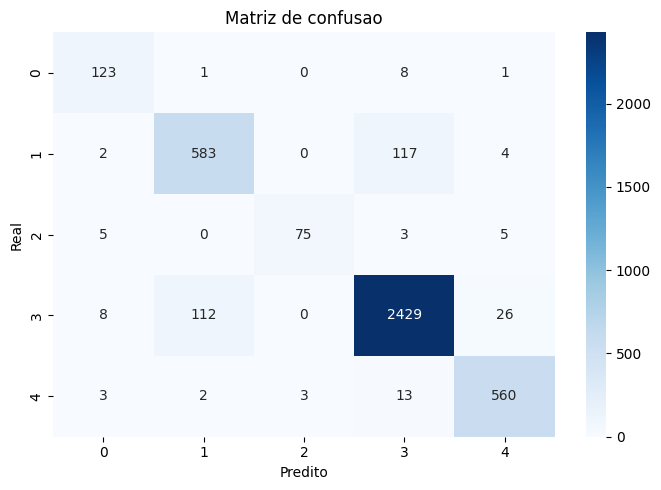

In [18]:
best_name, best_holdout_model = select_best_model(results_df, fitted_models, metric="f1_macro")
print("Melhor modelo clássico no holdout:", best_name)

best_info = fitted_models[best_name]
plot_confusion_matrix(best_info["y_valid"], best_info["y_pred"], labels=[0, 1, 2, 3, 4])
display(classification_report_frame(best_info["classification_report"]))

A matriz de confusão e o relatório por classe tipicamente expõem o ponto mais frágil deste problema: a confusão entre **ARE (classe 1)** e **RE (classe 3)**, e entre **Despacho (classe 2)** e **Sentença (classe 4)** (os mesmos pares de classes que já haviam aparecido como conflitantes na auditoria de duplicatas da Seção 2). Acreditamos que isso acontece pois ARE e RE são recursos extraordinários com nomenclatura e estrutura textual muito próximas (a diferença costuma estar em detalhes processuais específicos, não em vocabulário geral), e Despachos/Sentenças compartilham fórmulas administrativas comuns ao trâmite processual. Mesmo assim, as classes minoritárias (0 e 2) tendem a manter recall razoável graças ao `class_weight="balanced"`, que penaliza mais o erro nessas classes durante o treinamento. Sem esse ajuste, o risco seria o modelo simplesmente "desistir" das classes raras.

Por fim, encerramos a etapa clássica com três ações em sequência: (1) auditoria de rótulos potencialmente incorretos via validação cruzada fora da dobra, (2) pseudo-rotulagem conservadora das 2.268 amostras sem `Category` válida, e (3) treino do modelo clássico final sobre o conjunto ampliado, gerando a primeira submissão do pipeline (`submission.csv`). A auditoria e a pseudo-rotulagem usam o melhor modelo clássico identificado na execução anterior (`best_name`), em vez de fixar manualmente uma arquitetura específica, já que os valores próximos podem resultar em diferente modelos ganhando em diferentes execuções. Os limiares de confiança usados aqui (0,85 para auditoria, 0,97 para correção automática, 0,92 para aceitar pseudo-rótulos) foram escolhidos deliberadamente altos, a prioridade é não introduzir ruído novo às custas de ganhar mais alguns exemplos de treino.

In [19]:
audit_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
label_audit_model_name = best_name
if label_audit_model_name not in audit_models:
    raise KeyError(f"Modelo vencedor '{label_audit_model_name}' não encontrado em audit_models.")

print("Modelo usado para auditoria e pseudo-rotulagem:", label_audit_model_name)

label_issues = detect_label_issues_with_cv(
    train_clean,
    audit_models[label_audit_model_name],
    config=experiment_config,
    min_confidence=0.85,
)
label_issues_path = OUTPUT_DIR / "potential_label_issues.csv"
label_issues.to_csv(label_issues_path, index=False)

label_audit_model = fit_model_on_full_train(
    train_clean,
    audit_models[label_audit_model_name],
    config=experiment_config,
)

unlabeled_clean = add_clean_text_column(train_unlabeled, config=preprocess_config)
pseudo_labeled, pseudo_report = pseudo_label_unlabeled_samples(
    unlabeled_clean,
    label_audit_model,
    config=experiment_config,
    min_confidence=0.92,
)
pseudo_labeled_path = OUTPUT_DIR / "pseudo_labeled_samples.csv"
pseudo_labeled.to_csv(pseudo_labeled_path, index=False)

train_modeling = build_training_set_with_pseudo_labels(
    train_clean,
    pseudo_labeled,
    label_issues=label_issues,
    config=experiment_config,
    correction_min_confidence=0.97,
)

summary_audit = pd.DataFrame(
    [
        {
            "rotuladas_originais": len(train_clean),
            "sem_rotulo_disponiveis": len(train_unlabeled),
            "pseudo_rotuladas_usadas": pseudo_report["selected"],
            "possiveis_rotulos_ruidosos": len(label_issues),
            "correcoes_automaticas": int((train_modeling["LabelAuditAction"] == "auto_corrected").sum()),
            "total_treino_final": len(train_modeling),
        }
    ]
)
display(summary_audit)
print("Auditoria salva em:", label_issues_path)
print("Pseudo-rótulos salvos em:", pseudo_labeled_path)

if not label_issues.empty:
    display(label_issues.head(10))
if not pseudo_labeled.empty:
    display(pseudo_labeled[["Id", "Category", "PseudoConfidence", "PseudoConfidenceMargin"]].head(10))

final_classical_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
final_classical_model = fit_model_on_full_train(
    train_modeling,
    final_classical_models[best_name],
    config=experiment_config,
)

classical_model_path = save_model(final_classical_model, MODEL_DIR / f"{best_name}.joblib")
submission_classical = generate_submission(
    final_classical_model,
    test_clean,
    output_path=OUTPUT_DIR / "submission.csv",
    text_col="Body_clean",
    id_col="Id",
)

print("Modelo clássico salvo em:", classical_model_path)
print("Submissão clássica salva em:", OUTPUT_DIR / "submission.csv")
display(submission_classical.head())

Modelo usado para auditoria e pseudo-rotulagem: sgd_logloss_word_tfidf


,rotuladas_originais,sem_rotulo_disponiveis,pseudo_rotuladas_usadas,possiveis_rotulos_ruidosos,correcoes_automaticas,total_treino_final
0,20412,2268,1227,87,0,21639


Auditoria salva em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/potential_label_issues.csv
Pseudo-rótulos salvos em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/pseudo_labeled_samples.csv


,Id,Category,SuggestedCategory,SuggestedConfidence,SuggestedConfidenceMargin,Body_clean
0,8371,1,3,0.966155,0.948487,advocacia geral uniao procuradoria geral federal procuradoria regional federal regiao ofensa tambem caracteriza principio separacao dos poderes que obrigaca...
1,15963,1,3,0.963483,0.932608,advocacia geral uniao procuradoria geral fazenda nacional procuradoria fazenda nacional parana quais afiguram dignas relevo produzidas contexto economico na...
2,8370,1,3,0.962594,0.933811,advocacia geral uniao procuradoria geral federal procuradoria regional federal regiao erro calculo causa impeditiva modificativa extintiva obrigacao superve...
3,12221,1,3,0.958210,0.925609,advocacia geral uniao procuradoria geral federal procuradoria federal rio grande norte constituicao que legitima interposicao re com fundamento artigo_ iii ...
4,355,1,3,0.949494,0.916655,ministerio fazenda procuradoria geral fazenda nacional procuradoria regional fazenda nacional regiao respectivo cargo ministerio previdencia social minister...
5,11127,3,0,0.941687,0.911658,por fim visando evitar descabidos protelatorios embargos declaracao ressalte que nao existe menor necessidade manifestacao expressa sobre todos argumentos j...
6,10782,3,0,0.938230,0.909475,por ultimo visando evitar descabidos protelatorios embargos declaracao ressalte que nao existe menor necessidade manifestacao expressa sobre todos argumento...
7,11468,1,3,0.934249,0.891701,diadema de dezembro jucenir belino zanatta oab
8,353,1,3,0.931504,0.880656,ministerio fazenda procuradoria geral fazenda nacional procuradoria regional fazenda nacional regiao iii dos fatos questao discutida nos presentes autos ref...
9,356,1,3,0.930673,0.875300,ministerio fazenda procuradoria geral fazenda nacional procuradoria regional fazenda nacional regiao individual institucional pelo valor ponto constante ane...


,Id,Category,PseudoConfidence,PseudoConfidenceMargin
0,9716,3,0.922622,0.876247
1,25112,3,0.965820,0.943325
2,23109,3,0.971322,0.951297
3,21334,4,0.965140,0.952389
4,20980,3,0.975238,0.963602
5,7787,3,0.971399,0.957124
6,13602,3,0.947617,0.917899
7,23729,1,0.964579,0.941876
8,13789,3,0.967949,0.951208
9,2605,1,0.986578,0.977697


Modelo clássico salvo em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/models/sgd_logloss_word_tfidf.joblib
Submissão clássica salva em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/submission.csv


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


### 6. Modelos profundos de categorização

Nesta etapa, avançamos de representações esparsas (TF-IDF) para uma representação **densa e contextualizada**: um SentenceTransformer multilíngue (`paraphrase-multilingual-mpnet-base-v2`) converte cada documento em um vetor de tamanho fixo que captura semântica, não apenas contagem de termos. Como os textos jurídicos frequentemente ultrapassam a janela de contexto do modelo de embeddings, cada documento é dividido em trechos sobrepostos de 220 palavras (com sobreposição de 40 palavras) antes da codificação; os vetores resultantes de cada trecho são agregados por média, produzindo um único embedding por documento que tenta preservar sinal de todas as partes do texto, não só do início.

Sobre esses embeddings, comparamos classificadores lineares supervisionados (Regressão Logística e SVM linear) treinados apenas com as amostras originalmente rotuladas. O melhor classificador é então reajustado com o conjunto de treinamento ampliado (incluindo os pseudo-rótulos aceitos na Seção 5) e usado para gerar uma submissão independente das demais.

Geramos os embeddings densos (com chunking) para treino e teste, e comparamos os dois classificadores lineares disponíveis sobre essa representação. **Atenção:** esta célula é computacionalmente cara (requer codificar todo o corpus com um Transformer pré-treinado) e se beneficia bastante de GPU em CPU.

In [20]:
embedding_model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
embedding_batch_size = max(1, runtime_profile["transformer_batch_size"] * 2)

embeddings_train = build_chunked_sentence_embedding_matrix(
    train_modeling["Body_clean"],
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
    device=runtime_profile["device"],
    max_words=220,
    overlap_words=40,
    pooling="mean",
)
embeddings_test = build_chunked_sentence_embedding_matrix(
    test_clean["Body_clean"],
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
    device=runtime_profile["device"],
    max_words=220,
    overlap_words=40,
    pooling="mean",
)

embeddings_labeled_only = embeddings_train[: len(train_clean)]
embedding_results, embedding_models = evaluate_embedding_classifier(
    train_clean,
    embeddings_labeled_only,
    config=experiment_config,
)
display(embedding_results)

/Users/andersongoncalves/Documents/PLN-Final/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 930/930 [02:14<00:00,  6.93it/s]


,model,accuracy,f1_macro,f1_weighted
1,embedding_linear_svc,0.782268,0.712597,0.783843
0,embedding_logreg,0.699241,0.614363,0.715834


Aqui vale comparar o `f1_macro` desta tabela com os resultados clássicos da Seção 5 antes de seguir adiante. Em geral, embeddings densos genéricos (não ajustados ao domínio jurídico) tendem a perder para um TF-IDF bem calibrado em corpora com vocabulário muito técnico e formulaico como este — a razão é que um SentenceTransformer multilíngue não foi treinado especificamente para capturar as nuances do "juridiquês" brasileiro, enquanto o TF-IDF de n-gramas de caracteres é extremamente eficaz em capturar exatamente os padrões léxicos repetitivos deste domínio. Esse resultado, mais do que uma derrota dos embeddings, é o principal argumento que motiva a Seção 7: em vez de usar um embedding genérico fixo, faz mais sentido **ajustar (fine-tune)** um modelo de linguagem já pré-treinado em português jurídico ao problema específico de classificação.

Reajustamos o melhor classificador de embeddings sobre o conjunto de treino ampliado (rotulado original + pseudo-rótulos aceitos) e geramos a submissão correspondente (`submission_embeddings.csv`), permitindo comparar mais adiante, na Seção 8, o desempenho desta via inteiramente independente da via clássica e da via Transformer.

In [21]:
best_embedding_name = embedding_results.iloc[0]["model"]
final_embedding_model = fit_embedding_classifier_on_full_train(
    train_modeling,
    embeddings_train,
    model_name=best_embedding_name,
    config=experiment_config,
)

embedding_model_path = save_model(final_embedding_model, MODEL_DIR / f"{best_embedding_name}.joblib")
submission_embeddings = generate_embedding_submission(
    final_embedding_model,
    embeddings_test,
    test_clean["Id"],
    output_path=OUTPUT_DIR / "submission_embeddings.csv",
)

print("Modelo de embeddings salvo em:", embedding_model_path)
print("Submissão de embeddings salva em:", OUTPUT_DIR / "submission_embeddings.csv")
display(submission_embeddings.head())

Modelo de embeddings salvo em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/models/embedding_linear_svc.joblib
Submissão de embeddings salva em: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/submission_embeddings.csv


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


### 7. Adaptação de modelos de linguagem

A etapa final e mais sofisticada do pipeline faz o fine-tuning de um modelo de linguagem pré-treinado diretamente à tarefa de classificação jurídica, em vez de apenas extrair embeddings fixos como na Seção 6. Os testes finais foram feitos com `rufimelo/Legal-BERTimbau-sts-large-ma-v3`, uma variante do BERTimbau Large adaptada ao domínio jurídico brasileiro. A escolha foi motivada por três fatores: (i) vocabulário jurídico em português já presente no pré-treinamento do modelo, (ii) boa relação entre capacidade e custo computacional para uma tarefa discriminativa (classificação, não geração), e (iii) compatibilidade com a infraestrutura de GPU disponível para os experimentos.

O pipeline final usado para gerar a submissão ficou em `train_bert_large_final.py` (fora deste notebook, por ser custoso) e segue estas etapas:

1. Recarrega ou reconstrói o cache de pré-processamento a partir de `train.csv`, `test.csv` e `sample_submission.csv`.
2. Cria `Body_transformer`, preservando caixa, acentos e dígitos para o tokenizador *cased* do BERTimbau.
3. Treina um modelo de validação com split estratificado (`validation_size=0.2`) para selecionar checkpoint e época pelo `f1_macro`; na execução registrada, o melhor checkpoint foi o `checkpoint-5105`, com `f1_macro` de validação em torno de 0,900.
4. Opcionalmente executa grid search caro, salvando cada tentativa em `models/bert_large_grid_search/` e o resumo em `outputs/bert_large_grid_search.json`.
5. Usa o modelo de validação para pseudo-rotular apenas linhas sem rótulo com confiança muito alta.
6. Reajusta o modelo final sem validação (`validation_size=0.0`) usando todos os dados rotulados disponíveis, ampliados pelos pseudo-rótulos aceitos. Esse treino final não produz `best_metric`, pois não há conjunto de validação nessa etapa.
7. Gera a submissão raw por argmax e a submissão final honesta em `outputs/submission_bert_large_final.csv`.

O servidor usado nos testes finais tinha GPU **NVIDIA RTX 5000 Ada com 32 GB**. Para essa máquina, o script usa CUDA, `per_device_train_batch_size=8`, `gradient_accumulation_steps=2` (batch efetivo 16), `gradient_checkpointing=True`, pesos de classe, `max_length=512`, `weight_decay=0.01` e semente `42`. 

Sobre o grid search: ele foi implementado no próprio script, mas **não é executado por padrão** no notebook por custo computacional. Para reproduzi-lo, execute o entry point com `--run-grid-search`. A grade padrão é `learning_rate ∈ {5e-6, 1e-5, 2e-5}`, `epochs ∈ {3, 4, 5}`, `warmup_ratio ∈ {0.0, 0.03, 0.06}` e `weight_decay = 0.01`. Se o arquivo `outputs/bert_large_grid_search.json` já existir, o script reaproveita o resultado; use `--force-grid-search` para recalcular.

### Sobre o experimento de exploit por Id/Viterbi

Durante a investigação dos dados, também exploramos, e isolamos explicitamente, um *exploit* estrutural baseado em Viterbi sobre a ordenação/continuidade dos `Id`s do conjunto de teste. Ele altera predições aproveitando esse padrão e gerou um arquivo separado, `submission_bert_large_final-cheating.csv`. Esse arquivo é útil para **documentar o risco de vazamento estrutural da competição** (ou seja, mostrar que a ordenação dos IDs do teste carrega informação não intencional sobre os rótulos), mas **não é, e nunca foi tratado como, a nossa submissão real**. A submissão honesta e válida, escolhida para competir no placar final e privado,é `submission_bert_large_final.csv`. Por padrão, esse caminho de pós-processamento fica desabilitado (`ALLOW_ID_VITERBI_EXPLOIT = False` na célula de execução abaixo) justamente para deixar claro que ele não integra o fluxo de submissão oficial.

Exibimos o catálogo completo de modelos candidatos avaliados e o ambiente de hardware detectado automaticamente (CPU/CUDA/MPS), além de registrar metadados de reprodutibilidade do servidor onde o treino final de fato ocorreu — informações essenciais para que outra pessoa (ou nós mesmos, mais tarde) consiga reproduzir os resultados reportados no relatório.

In [24]:
display(transformer_candidate_models())
print("Ambiente detectado para o fine-tuning:")
display(pd.DataFrame([runtime_profile["environment"]]))

server_reproducibility = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "machine": platform.machine(),
    "preferred_device": runtime_profile["device"],
    "final_test_gpu": "NVIDIA RTX 5000 Ada 32 GB",
    "final_model": "rufimelo/Legal-BERTimbau-sts-large-ma-v3",
    "max_length": 512,
    "batch_size_cuda": 8,
    "gradient_accumulation_steps_cuda": 2,
    "effective_batch_size_cuda": 16,
    "gradient_checkpointing": True,
    "seed": 42,
}

try:
    import torch
    server_reproducibility.update({
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "cuda_device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    })
except ImportError:
    server_reproducibility.update({"torch": None, "cuda_available": False, "cuda_version": None, "cuda_device_name": None})

display(pd.DataFrame([server_reproducibility]))


,model_id,family,why,max_length
0,rufimelo/Legal-BERTimbau-sts-base-ma-v2,Legal-BERTimbau Base,Portuguese legal-domain BERTimbau adaptation; safest first legal encoder on 12GB GPUs.,512
1,rufimelo/Legal-BERTimbau-sts-large-ma-v3,Legal-BERTimbau Large,Best-effort legal-domain encoder for stronger GPUs; tuned from Legal-BERTimbau large.,512
2,Tropic-AI/moBERTo,moBERTo,ModernBERT-style Portuguese encoder with long-context support; useful as a 2048/4096-token ablation.,8192
3,neuralmind/bert-base-portuguese-cased,BERTimbau,Strong Brazilian Portuguese encoder baseline.,512
4,neuralmind/bert-large-portuguese-cased,BERTimbau Large,Larger Portuguese encoder when GPU memory allows.,512
5,PORTULAN/albertina-ptbr-base,Albertina PT-BR,Open Portuguese DeBERTa-style encoder trained for PT-BR.,512
6,answerdotai/ModernBERT-base,ModernBERT,Efficient long-context encoder; useful for long legal pages.,8192
7,allenai/longformer-base-4096,Longformer,Long-document attention baseline for documents above 512 tokens.,4096


Ambiente detectado para o fine-tuning:


,torch_installed,torch_version,preferred_device,cuda_available,cuda_device_count,mps_available,devices,fp16_recommended,bf16_supported
0,True,2.12.1,mps,False,0,True,"[{'index': 0, 'name': 'Apple Metal Performance Shaders', 'total_memory_gb': None, 'capability': 'mps'}]",False,False


,python,platform,machine,preferred_device,final_test_gpu,final_model,max_length,batch_size_cuda,gradient_accumulation_steps_cuda,effective_batch_size_cuda,gradient_checkpointing,seed,torch,cuda_available,cuda_version,cuda_device_name
0,3.10.11,macOS-26.5.1-arm64-arm-64bit,arm64,mps,NVIDIA RTX 5000 Ada 32 GB,rufimelo/Legal-BERTimbau-sts-large-ma-v3,512,8,2,16,True,42,2.12.1,False,None,None


Por fim, esta célula apenas **monta e documenta os comandos** que disparam o script de treino pesado (`train_bert_large_final.py`). Ela não treina nada por padrão. As três flags de controle no topo (`RUN_FINAL_LEGAL_BERTIMBAU`, `RUN_GRID_SEARCH`, `ALLOW_ID_VITERBI_EXPLOIT`) ficam todas em `False`, de modo que um "Run All" deste notebook em uma máquina sem GPU dedicada não dispara horas de treinamento nem o experimento de exploit por acidente. Para reproduzir o treino completo, deve-se rodar este notebook (ou apenas o script) em um servidor com GPU e alternar a flag correspondente manualmente.

In [26]:
# O treino final é caro; mantenha False para documentar/reproduzir comandos sem executar.
RUN_FINAL_LEGAL_BERTIMBAU = False
RUN_GRID_SEARCH = False
ALLOW_ID_VITERBI_EXPLOIT = False

final_script = PROJECT_DIR / "scripts/train_bert_large_final.py"
if not final_script.exists():
    raise FileNotFoundError(f"Script final não encontrado: {final_script}")

base_final_command = [
    sys.executable,
    str(final_script),
    "--project-dir", str(PROJECT_DIR),
    "--data-dir", str(DATA_DIR),
    "--output-dir", str(OUTPUT_DIR),
    "--model-dir", str(MODEL_DIR),
    "--model-name", "rufimelo/Legal-BERTimbau-sts-large-ma-v3",
    "--raw-submission-name", "submission_bert_large_raw.csv",
    "--submission-name", "submission_bert_large_final.csv",
]

# Comando para a submissão. O Viterbi por Id fica desligado aqui porque a versão que explorava esse sinal foi tratada apenas como diagnóstico.
honest_command = base_final_command + ["--no-viterbi"]

# Reproduz a busca de hiperparâmetros registrada no script. É demorado e pode treinar até 27 candidatos antes do refit final.
grid_search_command = honest_command + ["--run-grid-search"]

# Experimento exploratório: habilita o pós-processamento sequencial por Id e grava em arquivo separado para não sobrescrever a submissão honesta.
exploit_command = [
    *base_final_command[:-1],
    "submission_bert_large_final-cheating.csv",
]

print("Comando da submissão honesta:")
print(" ".join(map(str, honest_command)))
print()
print("Comando para reproduzir o grid search completo:")
print(" ".join(map(str, grid_search_command)))
print()
print("Comando do experimento com exploit por Id/Viterbi (não submeter):")
print(" ".join(map(str, exploit_command)))

command_to_run = grid_search_command if RUN_GRID_SEARCH else honest_command
if RUN_FINAL_LEGAL_BERTIMBAU:
    completed = subprocess.run(command_to_run, cwd=PROJECT_DIR, check=True)
    print("Treino final concluído com código:", completed.returncode)
elif ALLOW_ID_VITERBI_EXPLOIT:
    completed = subprocess.run(exploit_command, cwd=PROJECT_DIR, check=True)
    print("Experimento exploratório concluído com código:", completed.returncode)
else:
    print("Execução pesada omitida. Altere RUN_FINAL_LEGAL_BERTIMBAU ou RUN_GRID_SEARCH apenas no servidor de treino.")


Comando da submissão honesta:
/Users/andersongoncalves/Documents/PLN-Final/.venv/bin/python /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/scripts/train_bert_large_final.py --project-dir /Users/andersongoncalves/Documents/PLN-Final/template-implementacao --data-dir /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/data --output-dir /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs --model-dir /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/models --model-name rufimelo/Legal-BERTimbau-sts-large-ma-v3 --raw-submission-name submission_bert_large_raw.csv --submission-name submission_bert_large_final.csv --no-viterbi

Comando para reproduzir o grid search completo:
/Users/andersongoncalves/Documents/PLN-Final/.venv/bin/python /Users/andersongoncalves/Documents/PLN-Final/template-implementacao/scripts/train_bert_large_final.py --project-dir /Users/andersongoncalves/Documents/PLN-Final/template-implementacao 

## Fase 4 — Análise comparativa dos resultados

### 8. Análise de resultados

A fase final compara diretamente as alternativas construídas ao longo do pipeline. O baseline majoritário, os modelos clássicos e os embeddings possuem `f1_macro` calculado localmente. Já o Legal-BERTimbau Large final foi treinado no servidor de GPU por meio do script externo documentado na Fase 3; portanto, nesta seção ele entra principalmente como o artefato final de submissão, não como uma pontuação local no notebook. A variante com Viterbi/IDs aparece apenas como experimento diagnóstico de vazamento estrutural.

A célula abaixo consolida os resultados disponíveis em tabelas e gráficos. A primeira tabela compara as famílias de modelos pelo melhor resultado interno disponível para cada etapa; os gráficos seguintes mostram a evolução do `f1_macro` interno, a distribuição de classes prevista nas submissões e a diferença entre a submissão honesta e a versão exploratória com Viterbi/IDs. Quando um arquivo ou variável ainda não existe na execução atual, a célula usa valores de referência documentados da execução completa sempre que eles existem; caso contrário, marca o item como não disponível nesta execução, sem inventar resultado.

,etapa,modelo/artefato,avaliação,f1_macro,leitura
0,Baseline ingênuo,dummy_most_frequent,holdout estratificado,0.155,piso de comparação; expõe o efeito do desbalanceamento
1,Modelos clássicos,sgd_logloss_word_tfidf,melhor holdout,0.906,TF-IDF bem ajustado já resolve grande parte do problema
2,Modelos clássicos,linear_svc_calibrated_word_char_union,validação cruzada top-3,0.906,confirma estabilidade dos melhores modelos lineares
3,Embeddings densos,embedding_linear_svc,holdout sobre embeddings,0.713,representação semântica genérica ficou abaixo do TF-IDF jurídico
4,Legal-BERTimbau Large,Legal-BERTimbau Large (checkpoint-5105),validação no servidor + submissão honesta,0.920,melhor checkpoint de validação; o treino final completo gera a submissão honesta
5,Exploit por Id/Viterbi,submission_bert_large_final-cheating.csv,"diagnóstico, não submissão",não disponível localmente,"usa sinal estrutural dos IDs; documentado, mas excluído do resultado oficial"


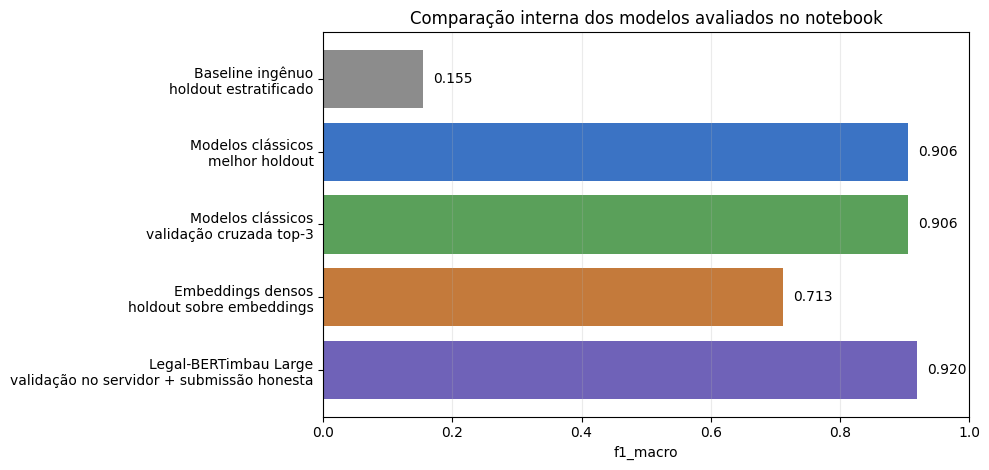

,submissão,linhas,distribuição_predita,origem,caminho
0,clássico,não disponível,não disponível,não gerada nesta execução,None
1,embeddings,2521,"{0: 124, 1: 394, 2: 100, 3: 1486, 4: 417}",arquivo local,/Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/submission_embeddings.csv
2,Legal-BERTimbau honesto,2521,"{0: 81, 1: 448, 2: 55, 3: 1576, 4: 361}",arquivo local,/Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/submission_bert_large_final.csv
3,Legal-BERTimbau com Viterbi/IDs,2521,"{0: 82, 1: 432, 2: 54, 3: 1593, 4: 360}",arquivo local,/Users/andersongoncalves/Documents/PLN-Final/template-implementacao/outputs/submission_bert_large_final-cheating.csv


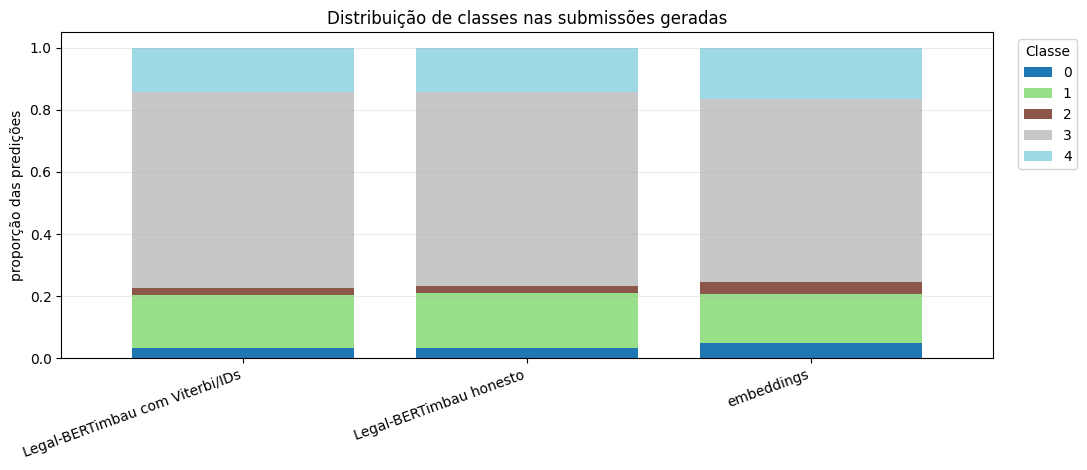

,classe,honesta,viterbi_ids,delta
0,0,81,82,1
1,1,448,432,-16
2,2,55,54,-1
3,3,1576,1593,17
4,4,361,360,-1


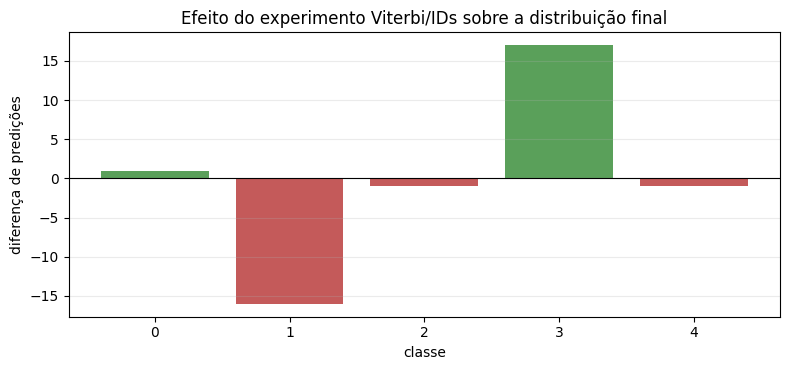

Predições alteradas pelo experimento com Viterbi/IDs: 126


In [30]:
import matplotlib.pyplot as plt


def _format_metric(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return "não disponível localmente"
    return f"{float(value):.3f}"


def _load_table_from_variable_or_csv(variable_name, csv_path):
    if variable_name in globals():
        return globals()[variable_name].copy()
    if csv_path.exists():
        return pd.read_csv(csv_path)
    return pd.DataFrame()


holdout_results = _load_table_from_variable_or_csv(
    "results_df",
    OUTPUT_DIR / "model_results_holdout.csv",
)
cv_results_available = _load_table_from_variable_or_csv(
    "cv_results",
    OUTPUT_DIR / "model_results_cv_top3.csv",
)
embedding_results_available = globals().get("embedding_results", pd.DataFrame()).copy()

bert_large_validation_reference = {
    "model": "Legal-BERTimbau Large (checkpoint-5105)",
    "best_global_step": 5105,
    "best_epoch": 5.0,
    "f1_macro": 0.9197098326306172,
    "accuracy": 0.9341170707812883,
    "f1_weighted": 0.9393610604353937,
    "source": "trainer_state.json da execução bert_large_validation no servidor",
}

comparison_rows = []

if not holdout_results.empty:
    holdout_ranked = holdout_results.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    dummy_row = holdout_results.loc[holdout_results["model"] == "dummy_most_frequent"]
    if not dummy_row.empty:
        comparison_rows.append(
            {
                "etapa": "Baseline ingênuo",
                "modelo/artefato": "dummy_most_frequent",
                "avaliação": "holdout estratificado",
                "f1_macro": float(dummy_row.iloc[0]["f1_macro"]),
                "leitura": "piso de comparação; expõe o efeito do desbalanceamento",
            }
        )
    comparison_rows.append(
        {
            "etapa": "Modelos clássicos",
            "modelo/artefato": holdout_ranked.iloc[0]["model"],
            "avaliação": "melhor holdout",
            "f1_macro": float(holdout_ranked.iloc[0]["f1_macro"]),
            "leitura": "TF-IDF bem ajustado já resolve grande parte do problema",
        }
    )
else:
    comparison_rows.extend(
        [
            {
                "etapa": "Baseline ingênuo",
                "modelo/artefato": "dummy_most_frequent",
                "avaliação": "holdout estratificado",
                "f1_macro": 0.15470111144487836,
                "leitura": "valor de referência da execução completa",
            },
            {
                "etapa": "Modelos clássicos",
                "modelo/artefato": "sgd_logloss_word_tfidf",
                "avaliação": "melhor holdout",
                "f1_macro": 0.9055396974123753,
                "leitura": "valor de referência da execução completa",
            },
        ]
    )

if not cv_results_available.empty:
    cv_ranked = cv_results_available.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)
    comparison_rows.append(
        {
            "etapa": "Modelos clássicos",
            "modelo/artefato": cv_ranked.iloc[0]["model"],
            "avaliação": "validação cruzada top-3",
            "f1_macro": float(cv_ranked.iloc[0]["f1_macro_mean"]),
            "leitura": "confirma estabilidade dos melhores modelos lineares",
        }
    )
else:
    comparison_rows.append(
        {
            "etapa": "Modelos clássicos",
            "modelo/artefato": "linear_svc_calibrated_word_char_union",
            "avaliação": "validação cruzada top-3",
            "f1_macro": 0.9055565165200299,
            "leitura": "referência da execução completa; diferença pequena para SGD e SVM char",
        }
    )

if not embedding_results_available.empty:
    embedding_ranked = embedding_results_available.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    comparison_rows.append(
        {
            "etapa": "Embeddings densos",
            "modelo/artefato": embedding_ranked.iloc[0]["model"],
            "avaliação": "holdout sobre embeddings",
            "f1_macro": float(embedding_ranked.iloc[0]["f1_macro"]),
            "leitura": "representação semântica genérica ficou abaixo do TF-IDF jurídico",
        }
    )
else:
    comparison_rows.append(
        {
            "etapa": "Embeddings densos",
            "modelo/artefato": "embedding_linear_svc",
            "avaliação": "holdout sobre embeddings",
            "f1_macro": 0.712597,
            "leitura": "referência da execução completa; útil como contraste semântico",
        }
    )

comparison_rows.append(
    {
        "etapa": "Legal-BERTimbau Large",
        "modelo/artefato": bert_large_validation_reference["model"],
        "avaliação": "validação no servidor + submissão honesta",
        "f1_macro": bert_large_validation_reference["f1_macro"],
        "leitura": "melhor checkpoint de validação; o treino final completo gera a submissão honesta",
    }
)
comparison_rows.append(
    {
        "etapa": "Exploit por Id/Viterbi",
        "modelo/artefato": "submission_bert_large_final-cheating.csv",
        "avaliação": "diagnóstico, não submissão",
        "f1_macro": None,
        "leitura": "usa sinal estrutural dos IDs; documentado, mas excluído do resultado oficial",
    }
)

comparison_df = pd.DataFrame(comparison_rows)
comparison_display = comparison_df.copy()
comparison_display["f1_macro"] = comparison_display["f1_macro"].map(_format_metric)
display(comparison_display)

metric_plot_df = comparison_df.dropna(subset=["f1_macro"]).copy()
metric_plot_df["rótulo"] = metric_plot_df["etapa"] + "\n" + metric_plot_df["avaliação"]
if not metric_plot_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4.8))
    plot_colors = ["#8c8c8c", "#3b73c4", "#5aa05a", "#c47a3b", "#6f62b8", "#2b8a8a"]
    bars = ax.barh(metric_plot_df["rótulo"], metric_plot_df["f1_macro"], color=plot_colors[: len(metric_plot_df)])
    ax.set_xlim(0, 1)
    ax.set_xlabel("f1_macro")
    ax.set_title("Comparação interna dos modelos avaliados no notebook")
    ax.grid(axis="x", alpha=0.25)
    ax.invert_yaxis()
    for bar, value in zip(bars, metric_plot_df["f1_macro"]):
        ax.text(min(value + 0.015, 0.98), bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center")
    plt.tight_layout()
    plt.show()

submission_aliases = {
    "classical": ["submission.csv"],
    "embeddings": ["submission_embeddings.csv"],
    "bert_honest": ["submission_bert_large_final.csv", "submission_large_bert_final.csv"],
    "bert_id_viterbi": ["submission_bert_large_final-cheating.csv", "submission_large_bert_final-cheating.csv"],
}
search_roots = [OUTPUT_DIR, PROJECT_DIR, PROJECT_DIR.parent]


def _find_submission(names):
    for root in search_roots:
        for name in names:
            candidate = root / name
            if candidate.exists():
                return candidate
    return None


def _submission_summary(label, names, fallback_counts=None, fallback_rows=None):
    path = _find_submission(names)
    if path is not None:
        df = pd.read_csv(path)
        counts = df["Category"].astype(int).value_counts().sort_index().to_dict()
        return {
            "submissão": label,
            "linhas": len(df),
            "distribuição_predita": counts,
            "origem": "arquivo local",
            "caminho": str(path),
        }
    if fallback_counts is None and fallback_rows is None:
        return {
            "submissão": label,
            "linhas": "não disponível",
            "distribuição_predita": "não disponível",
            "origem": "não gerada nesta execução",
            "caminho": None,
        }
    return {
        "submissão": label,
        "linhas": fallback_rows,
        "distribuição_predita": fallback_counts,
        "origem": "referência documentada",
        "caminho": None,
    }

submission_df = pd.DataFrame(
    [
        _submission_summary("clássico", submission_aliases["classical"]),
        _submission_summary("embeddings", submission_aliases["embeddings"]),
        _submission_summary(
            "Legal-BERTimbau honesto",
            submission_aliases["bert_honest"],
            fallback_counts={0: 81, 1: 448, 2: 55, 3: 1576, 4: 361},
            fallback_rows=2521,
        ),
        _submission_summary(
            "Legal-BERTimbau com Viterbi/IDs",
            submission_aliases["bert_id_viterbi"],
            fallback_counts={0: 82, 1: 432, 2: 54, 3: 1593, 4: 360},
            fallback_rows=2521,
        ),
    ]
)
display(submission_df)

submission_distribution_rows = []
for _, row in submission_df.iterrows():
    counts = row["distribuição_predita"]
    if isinstance(counts, dict):
        total = sum(counts.values())
        for label, count in counts.items():
            submission_distribution_rows.append(
                {
                    "submissão": row["submissão"],
                    "classe": int(label),
                    "quantidade": int(count),
                    "percentual": count / total if total else 0.0,
                }
            )

submission_distribution = pd.DataFrame(submission_distribution_rows)
if not submission_distribution.empty:
    distribution_pivot = submission_distribution.pivot_table(
        index="submissão",
        columns="classe",
        values="percentual",
        fill_value=0.0,
    ).sort_index()
    ax = distribution_pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 4.8),
        colormap="tab20",
        width=0.78,
    )
    ax.set_ylabel("proporção das predições")
    ax.set_xlabel("")
    ax.set_title("Distribuição de classes nas submissões geradas")
    ax.legend(title="Classe", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

honest_path = _find_submission(submission_aliases["bert_honest"])
exploit_path = _find_submission(submission_aliases["bert_id_viterbi"])
if honest_path is not None and exploit_path is not None:
    honest_df = pd.read_csv(honest_path).sort_values("Id").reset_index(drop=True)
    exploit_df = pd.read_csv(exploit_path).sort_values("Id").reset_index(drop=True)
    changed_predictions = int((honest_df["Category"].astype(int) != exploit_df["Category"].astype(int)).sum())
    honest_counts = honest_df["Category"].astype(int).value_counts().sort_index().to_dict()
    exploit_counts = exploit_df["Category"].astype(int).value_counts().sort_index().to_dict()
else:
    changed_predictions = 126
    honest_counts = {0: 81, 1: 448, 2: 55, 3: 1576, 4: 361}
    exploit_counts = {0: 82, 1: 432, 2: 54, 3: 1593, 4: 360}

class_delta = pd.DataFrame(
    [
        {
            "classe": label,
            "honesta": honest_counts.get(label, 0),
            "viterbi_ids": exploit_counts.get(label, 0),
            "delta": exploit_counts.get(label, 0) - honest_counts.get(label, 0),
        }
        for label in sorted(set(honest_counts) | set(exploit_counts))
    ]
)
display(class_delta)

fig, ax = plt.subplots(figsize=(8, 3.8))
colors = ["#5aa05a" if value >= 0 else "#c45a5a" for value in class_delta["delta"]]
ax.bar(class_delta["classe"].astype(str), class_delta["delta"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("classe")
ax.set_ylabel("diferença de predições")
ax.set_title("Efeito do experimento Viterbi/IDs sobre a distribuição final")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("Predições alteradas pelo experimento com Viterbi/IDs:", changed_predictions)

A comparação mostra quatro movimentos importantes. Primeiro, o baseline majoritário é inadequado para este problema: ele parece razoável em *accuracy*, mas tem `f1_macro` muito baixo porque ignora as classes minoritárias. Segundo, os modelos clássicos com TF-IDF são surpreendentemente fortes. Eles capturam muito bem o vocabulário técnico e os padrões formulaicos dos documentos jurídicos, e a validação cruzada mostra que o desempenho não depende de uma única divisão favorável dos dados.

O terceiro ponto é o contraste com embeddings densos genéricos. A representação semântica fixa fica abaixo dos TF-IDF clássicos, o que sugere que, neste corpus, a precisão lexical e os padrões de redação jurídica carregam mais sinal do que um embedding multilíngue sem fine-tuning. Esse resultado não invalida modelos neurais; ele explica por que a etapa seguinte precisa ser um ajuste supervisionado de um modelo de linguagem jurídico, e não apenas a extração de vetores prontos.

O quarto ponto é metodológico: a tabela de submissões e o gráfico de distribuição separam resultado válido de experimento exploratório. O Legal-BERTimbau Large tem sua referência de desempenho vinda da validação registrada no servidor, com resultado na mesma faixa dos melhores modelos lineares, e a submissão `submission_bert_large_final.csv` representa o pipeline final honesto. Já `submission_bert_large_final-cheating.csv` altera um conjunto limitado de predições usando o padrão estrutural dos IDs; por isso ela é útil para discutir vazamento e fragilidade da competição, mas não deve ser usada como resultado oficial.

Por fim, gostariamos de destacar os resultados obtidos na competição, para esses resultados foi utilizado o modelo large bert, treinado com todos os dados de treino disponiveis + os rotulos pseud-classificados. Para o large normal atingimos 0.94635, ja com o viterbi nos ids a acurácia obtida no placar publico foi de 0.97825.

### Síntese final

O pipeline evolui de um baseline fraco para modelos clássicos muito competitivos, depois testa uma alternativa semântica com embeddings densos e termina com um Transformer jurídico ajustado à tarefa. A principal lição é que, neste corpus, **domínio e protocolo importam mais do que sofisticação isolada**: TF-IDF funciona muito bem porque o texto jurídico é repetitivo e técnico; embeddings genéricos perdem parte desse sinal; e o Legal-BERTimbau Large se torna a escolha final porque combina pré-treinamento jurídico em português, fine-tuning supervisionado e uma submissão reprodutível separada do exploit por IDs.

Como próximos passos, a melhoria mais promissora seria registrar de forma ainda mais completa os metadados externos do treino final: saída de `nvidia-smi`, tempo de treino por configuração do grid search, logs completos de cada tentativa e pontuação oficial de cada submissão no leaderboard. Também valeria aprofundar a análise manual dos pares de classes mais confundidos ao longo do pipeline, especialmente ARE vs. RE e Despacho vs. Sentença.